In [2]:
import numpy as np
import torch
from ase.calculators.calculator import Calculator, all_properties
from ase.neighborlist import neighbor_list

# ============================================================
# PHYSICAL BASELINE VALUES INITIALIZATION
# ============================================================
ATOMIC_REFS = {
    8: -14.4981, 39: 3.8160, 40: 1.0342, 41: 2.1881,
    57: 5.6295,  58: 2.8697, 60: 5.8286, 63: 1.8170,
    64: -3.1563, 71: 5.7609, 90: 0.0736, 91: -2.4681,
    92: -3.1598, 93: -3.6084, 94: -4.5609, 95: -5.4599,
    96: -7.2799, 98: -6.5734
}
MAX_Z = max(ATOMIC_REFS.keys())
REF_LOOKUP = np.zeros(MAX_Z + 1, dtype=np.float32)
for z, ref_val in ATOMIC_REFS.items():
    REF_LOOKUP[z] = ref_val


def canonical_atom_order(atoms):
    """Must match dataset.py's canonicalization exactly (species, then centroid distance, then index)."""
    Z = atoms.get_atomic_numbers()
    pos = atoms.get_positions(wrap=True)
    centroid = pos.mean(axis=0, keepdims=True)
    d_centroid = np.linalg.norm(pos - centroid, axis=-1)
    return np.lexsort((np.arange(len(Z)), d_centroid, Z))


class CompiledMLIPCalculator(Calculator):
    """
    Same canonical-ordering and force-conservation corrections as the
    static calculator.py, PLUS explicit autoregressive magnetic-moment
    propagation: mu^(t) = mu_hat^(t-1), predicted internally by the model
    and written back into `self.atoms` at the end of every calculate()
    call, so the NEXT call's atoms.get_initial_magnetic_moments() reads
    the model's own previous-step prediction rather than a static value.

    IMPORTANT: predicted moments come out of the model in CANONICAL order
    (same as forces would if they weren't autograd-derived). Unlike
    forces -- which are automatically returned in original atom order
    because they're computed via autograd w.r.t. the original `positions`
    tensor -- magmoms are a direct network output and must be scattered
    back from canonical to raw atom order EXPLICITLY before being written
    to `atoms`. Skipping this step silently assigns each predicted moment
    to the wrong physical atom whenever canonical order != raw order,
    which is the general case at every MD step (see kenji_eval.py, where
    this exact bug was found and fixed for evaluation-time magmom output).

    Usage note: for t=0 / unseen structures, set the initial guess via
    atoms.set_initial_magnetic_moments(...) BEFORE attaching this
    calculator and starting the dynamics -- this calculator only handles
    propagation for t>0, not the initial guess itself.
    """
    implemented_properties = ['energy', 'forces', 'magmoms']

    def __init__(self, compiled_model_path, device=torch.device("cpu"), r_cut=7.0):
        super().__init__()
        print(f"📦 Loading pre-compiled graph into memory stream: {compiled_model_path}")
        cpu_model = torch.jit.load(compiled_model_path, map_location="cpu")
        self.model = cpu_model.float().eval()
        self.device = device
        self.r_cut = r_cut

    def calculate(self, atoms=None, properties=['energy'], system_changes=all_properties):
        super().calculate(atoms, properties, system_changes)

        num_atoms = len(self.atoms)
        atomic_numbers_raw = self.atoms.get_atomic_numbers()

        # --- canonical order, must match dataset.py ---
        order = canonical_atom_order(self.atoms)
        order_t = torch.tensor(order, dtype=torch.long, device=self.device)
        atoms_canon = self.atoms[order]

        # --- differentiable positions (original order) ---
        positions = torch.tensor(self.atoms.get_positions(), dtype=torch.float32, device=self.device)
        positions.requires_grad_(True)
        pos_canon = positions[order_t]

        atomic_numbers_canon = atomic_numbers_raw[order]
        atomic_numbers_tensor = torch.tensor(atomic_numbers_canon, dtype=torch.long, device=self.device)

        # --- neighbor list computed directly on canonical-order Atoms ---
        idx_i, idx_j, displacements = neighbor_list('ijD', atoms_canon, self.r_cut)
        edge_index = torch.tensor(np.stack([idx_i, idx_j]), dtype=torch.long, device=self.device)
        edge_vec = torch.tensor(displacements, dtype=torch.float32, device=self.device)

        dr_open = pos_canon[edge_index[1]] - pos_canon[edge_index[0]]
        with torch.no_grad():
            cell_offsets = edge_vec - dr_open
        dynamic_edge_vec = dr_open + cell_offsets

        distances = torch.norm(dynamic_edge_vec, dim=-1)
        envelope = 0.5 * (torch.cos(np.pi * distances / self.r_cut) + 1.0)
        envelope = torch.where(distances < self.r_cut, envelope, torch.zeros_like(envelope))
        enveloped_distances = distances * envelope

        dist_matrix = torch.zeros((num_atoms, num_atoms), dtype=torch.float32, device=self.device)
        if len(idx_i) > 0:
            dist_matrix[edge_index[0], edge_index[1]] = enveloped_distances
        eye = torch.eye(num_atoms, dtype=torch.float32, device=self.device)
        dist_matrix = dist_matrix + eye

        # --- Spin input: THIS IS mu^(t-1) -- either the initial guess (t=0,
        # set by the user before starting dynamics) or the model's own
        # prediction from the previous step, written back at the end of
        # the previous calculate() call (see bottom of this method). ---
        try:
            spin_np_raw = np.array(self.atoms.get_initial_magnetic_moments())
        except Exception:
            spin_np_raw = np.zeros(num_atoms)
        spin_np_raw = np.nan_to_num(spin_np_raw)
        spin_np = spin_np_raw[order]

        spin_t = torch.tensor(spin_np, dtype=torch.float32, device=self.device)

        spin_pair = torch.tanh(spin_t[:, None] * spin_t[None, :])
        spin_dist = spin_pair * torch.exp(-dist_matrix)
        diag_spin = torch.zeros_like(spin_pair)
        diag_spin.diagonal().copy_(spin_t)

        eps = 1e-8
        spin_pair = torch.tanh(spin_pair / (torch.std(spin_pair) + eps))
        spin_dist = torch.tanh(spin_dist / (torch.std(spin_dist) + eps))
        diag_spin = torch.tanh(diag_spin / (torch.std(diag_spin) + eps))

        channels = torch.stack([spin_pair, spin_dist, diag_spin], dim=0)
        matrix_images = torch.tanh(channels).unsqueeze(0)

        matrix_mapping = torch.stack([
            torch.zeros(num_atoms, device=self.device),
            torch.arange(num_atoms, device=self.device)
        ], dim=-1).long()

        batch_indices = torch.zeros(num_atoms, dtype=torch.long, device=self.device)

        pred_energy, pred_magmoms = self.model(
            pos_canon,
            atomic_numbers_tensor,
            edge_index,
            dynamic_edge_vec,
            matrix_images,
            matrix_mapping,
            batch_indices
        )
        pred_energy_flat = pred_energy.view(-1)

        baseline_energy = REF_LOOKUP[atomic_numbers_raw].sum()
        total_energy_ev = pred_energy_flat.item() + baseline_energy

        # --------------------------------------------------------
        # Forces: autograd w.r.t. the ORIGINAL positions tensor, so the
        # result is already in original atom order (see calculator.py).
        # --------------------------------------------------------
        forces_grad_tuple = torch.autograd.grad(
            outputs=pred_energy_flat,
            inputs=positions,
            grad_outputs=torch.ones_like(pred_energy_flat),
            create_graph=False,
            retain_graph=False,
            only_inputs=True
        )

        self.results['energy'] = total_energy_ev
        self.results['forces'] = -forces_grad_tuple[0].detach().cpu().numpy().astype(np.float64)

        # --------------------------------------------------------
        # Magmoms: a DIRECT network output, in CANONICAL order. Must be
        # explicitly scattered back to raw atom order -- it does NOT
        # auto-unpermute the way autograd-derived forces do.
        # --------------------------------------------------------
        pred_magmoms_canon = pred_magmoms.detach().cpu().numpy().astype(np.float64).reshape(-1)
        if pred_magmoms_canon.shape[0] != num_atoms:
            self.results['magmoms'] = pred_magmoms_canon  # shape mismatch -- leave as-is, caller should check
        else:
            pred_magmoms_raw_order = np.empty(num_atoms, dtype=np.float64)
            pred_magmoms_raw_order[order] = pred_magmoms_canon
            self.results['magmoms'] = pred_magmoms_raw_order

            # --------------------------------------------------------
            # AUTOREGRESSIVE FEEDBACK: mu^(t) = mu_hat^(t-1).
            # Write the (correctly un-permuted, raw-order) predicted
            # moments back into `self.atoms` so the NEXT calculate() call
            # -- at the next MD step, after the integrator has moved the
            # atoms -- reads these as its input mu^(t-1) via
            # atoms.get_initial_magnetic_moments(). This is the actual
            # mechanism implementing the propagation equation described
            # in the manuscript; without this line, moments would remain
            # frozen at whatever was set before dynamics started.
            # --------------------------------------------------------
            self.atoms.set_initial_magnetic_moments(pred_magmoms_raw_order)

🖥️ Target Compute Context Assigned: cpu
📦 Loading pre-compiled graph into memory stream: KENJI.ptc
📖 Parsing experimental crystal lattice coordinates from database file: UO2.cif

⏳ Step 1: Running Initial Geometry Relaxation...
      Step     Time          Energy          fmax
BFGS:    0 16:36:23      -30.335093        0.000001
📐 Relaxed Cell Volume: 40.559 Å³
🔗 Relaxed U-O Average Bond Length: 2.3617 Å
   (Min: 2.3617 Å | Max: 2.3617 Å)

📈 Step 3: Executing Equation of State (EOS) Scans...
Scale    | Volume (Å³)  | Avg U-O Dist (Å)   | Energy (eV) 
------------------------------------------------------------
0.90     | 29.568       | 2.1255             | -28.5808    
0.91     | 30.998       | 2.1592             | -28.7323    
0.93     | 32.474       | 2.1930             | -29.4378    
0.94     | 33.996       | 2.2267             | -29.8548    
0.96     | 35.565       | 2.2604             | -30.1507    
0.97     | 37.181       | 2.2942             | -30.2610    
0.99     | 38.846      

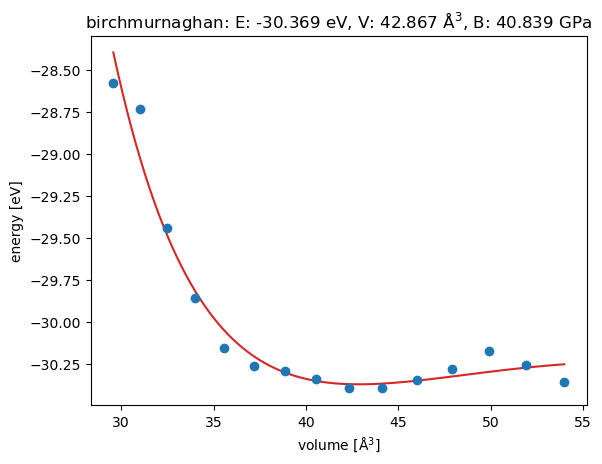

In [2]:
import os
import torch
import numpy as np
from ase.io import read
from ase.optimize import BFGS
from ase import units
from ase.eos import EquationOfState

def analyze_uo_distances(atoms):
    """
    Computes periodic-boundary-aware U-O bond distances in the system.
    """
    # 1. Identify indices for Uranium (Z=92) and Oxygen (Z=8)
    chemical_symbols = np.array(atoms.get_chemical_symbols())
    u_indices = np.where(chemical_symbols == 'U')[0]
    o_indices = np.where(chemical_symbols == 'O')[0]
    
    if len(u_indices) == 0 or len(o_indices) == 0:
        print("⚠️ Warning: Structure does not contain both U and O atoms.")
        return []

    # 2. Get periodic-boundary-aware distance vectors from all U to all O atoms
    # mic=True enforces the Minimum Image Convention across the cell boundaries
    all_distances = []
    for u_idx in u_indices:
        distances_to_o = atoms.get_distances(u_idx, o_indices, mic=True)
        all_distances.extend(distances_to_o)
        
    all_distances = np.array(all_distances)
    
    # 3. Filter for first-nearest-neighbor shell (typically ~2.1 to ~2.5 Å for U-O)
    # This ignores long-range unbonded cross-cell U-O pairs
    bonded_cut = 2.8 
    uo_bonds = all_distances[all_distances < bonded_cut]
    
    return uo_bonds

def main():
    device = torch.device("cpu")
    print(f"🖥️ Target Compute Context Assigned: {device}")
    
    # Configure path pointing to your model file footprint
    calc = CompiledMLIPCalculator("KENJI.ptc", device, r_cut=5.0)
    
    # CRUCIAL: Point this directly to your downloaded database file name
    cif_file_path = "UO2.cif"
    if not os.path.exists(cif_file_path):
        raise FileNotFoundError(f"❌ Missing mandatory CIF input path: {cif_file_path}. Please place it in this directory.")

    print(f"📖 Parsing experimental crystal lattice coordinates from database file: {cif_file_path}")
    unit_cell = read(cif_file_path)
    
    # Scale unit cell to establish standard 2x2x2 supercell dimension blocks
    bulk_amo2 = unit_cell #* (2, 2, 2)
    bulk_amo2.set_pbc((True, True, True))
    bulk_amo2.set_initial_magnetic_moments(np.ones(len(bulk_amo2)) * 0.6)
    bulk_amo2.calc = calc

    # --------------------------------------------------------
    # STEP 1: INITIAL BFGS STRUCTURAL MINIMIZATION
    # --------------------------------------------------------
    print("\n⏳ Step 1: Running Initial Geometry Relaxation...")
    opt = BFGS(bulk_amo2, trajectory='relaxation_track.traj')
    opt.run(fmax=0.05, steps=500) 
    relaxed_cell = read('relaxation_track.traj', index=-1)
    print(f"📐 Relaxed Cell Volume: {relaxed_cell.get_volume():.3f} Å³")

    # NEW: Analyze U-O Bonds after relaxation
    relaxed_uo_bonds = analyze_uo_distances(relaxed_cell)
    if len(relaxed_uo_bonds) > 0:
        print(f"🔗 Relaxed U-O Average Bond Length: {np.mean(relaxed_uo_bonds):.4f} Å")
        print(f"   (Min: {np.min(relaxed_uo_bonds):.4f} Å | Max: {np.max(relaxed_uo_bonds):.4f} Å)")

    # --------------------------------------------------------
    # STEP 3: STATIC EQUATION OF STATE (EOS) DEFORMATION
    # --------------------------------------------------------
    print("\n📈 Step 3: Executing Equation of State (EOS) Scans...")
    volumes, energies = [], []
    scale_factors = np.linspace(0.90, 1.10, 15)
    
    print(f"{'Scale':<8} | {'Volume (Å³)':<12} | {'Avg U-O Dist (Å)':<18} | {'Energy (eV)':<12}")
    print("-" * 60)
    
    for scale in scale_factors:
        test_atoms = relaxed_cell.copy()
        test_atoms.calc = calc
        test_atoms.set_cell(relaxed_cell.cell * scale, scale_atoms=True)
        
        # Track the active U-O bond stretching dynamically as the lattice expands/contracts
        current_uo_bonds = analyze_uo_distances(test_atoms)
        avg_uo_dist = np.mean(current_uo_bonds) if len(current_uo_bonds) > 0 else 0.0
        
        vol = test_atoms.get_volume()
        eng = test_atoms.get_potential_energy()
        
        volumes.append(vol)
        energies.append(eng)
        
        print(f"{scale:<8.2f} | {vol:<12.3f} | {avg_uo_dist:<18.4f} | {eng:<12.4f}")

    eos = EquationOfState(volumes, energies, eos='birchmurnaghan')
    v0, e0, B = eos.fit()
    print(f"\n✅ EOS Fitted Equilibrium Volume: {v0:.3f} Å³ | Bulk Modulus: {B / units.GPa:.2f} GPa")
    
    # Calculate equilibrium U-O distance by scaling relaxed cell to the EOS v0 volume layout
    eq_cell = relaxed_cell.copy()
    eq_scale = (v0 / relaxed_cell.get_volume()) ** (1/3)
    eq_cell.set_cell(relaxed_cell.cell * eq_scale, scale_atoms=True)
    eq_uo_bonds = analyze_uo_distances(eq_cell)
    print(f"⭐ Predicted Equilibrium U-O Bond Distance: {np.mean(eq_uo_bonds):.4f} Å")
    
    eos.plot('uo2_eos_curve.png')

if __name__ == "__main__":
    main()

Running on: cpu
📦 Loading pre-compiled graph into memory stream: KENJI.ptc
Atoms (N)  | E_tot (eV)     | E/atom (eV)    | Time/step (ms)  | Peak RSS (MB)
96         | -1057.0981     | -11.01143932   | 519.40          | 748.2       
324        | -3567.8140     | -11.01177120   | 2301.81         | 1643.4      
768        | -8457.1016     | -11.01185131   | 6264.62         | 3377.7      
1500       | -16517.8203    | -11.01187992   | 13953.57        | 6302.2      
2592       | -28542.8242    | -11.01189232   | 20432.94        | 8979.2      

✅ Cell Replication Invariance Check: Max |E_per_atom diff| = 4.53e-04 eV/atom
   NOTE: each evaluation above used a tiny (1e-6 A) random position
   perturbation to force real recomputation. This invariance check
   is therefore approximate at the ~1e-6-scale level, not exact --
   which is appropriate, since it also incidentally guards against
   the fixed-geometry case landing exactly on a canonical-order tie.

✅ Scaling figures saved successfully t

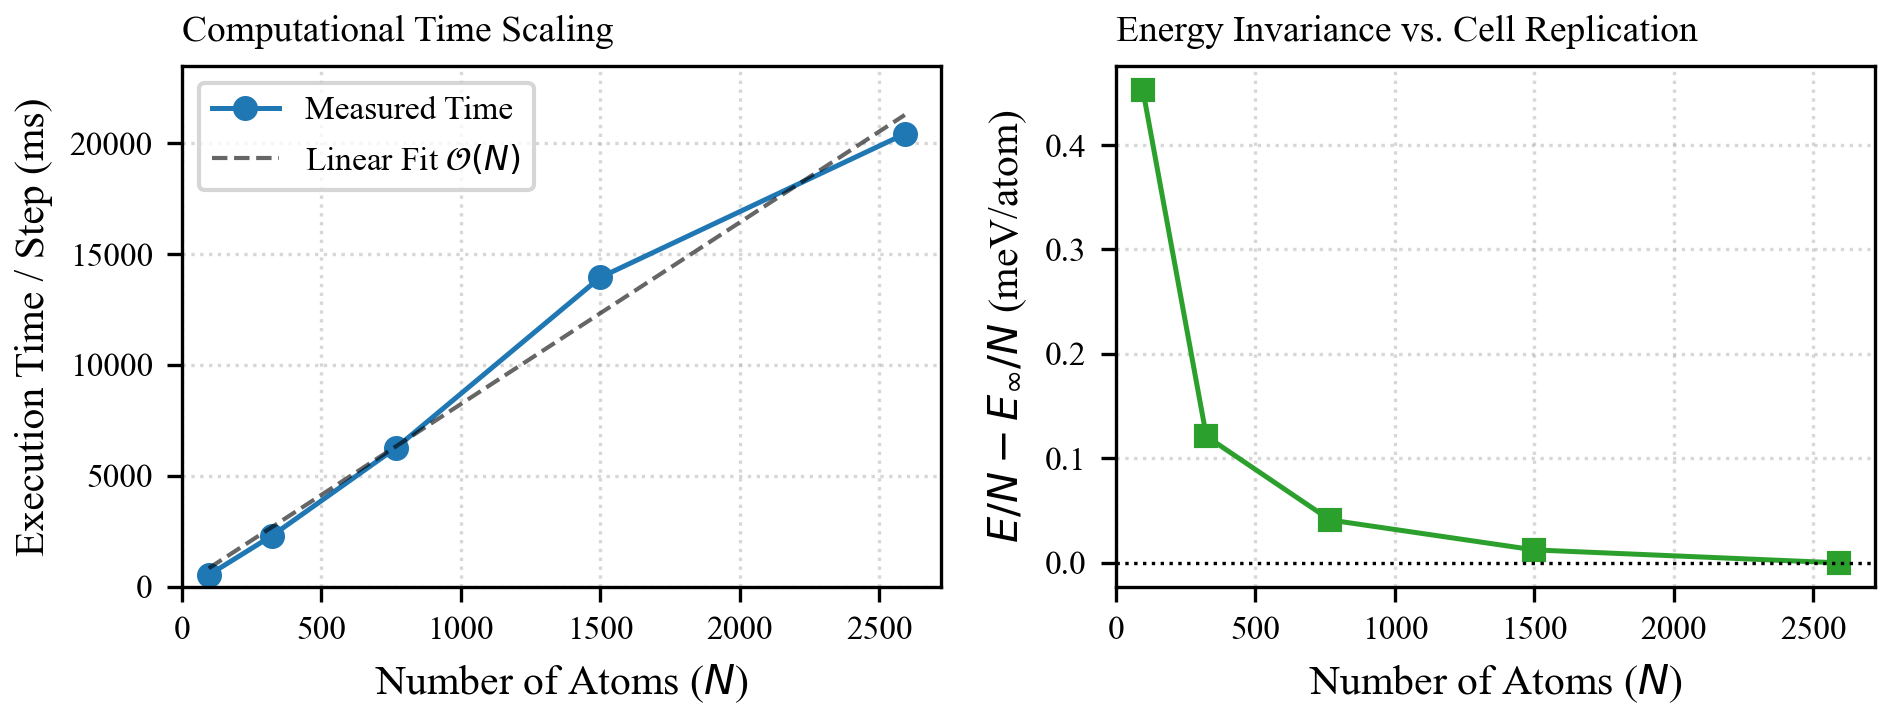


--- Peak process RSS by supercell size (CPU, cumulative across run) ---
  N=    96 atoms | peak RSS so far:    748.2 MB
  N=   324 atoms | peak RSS so far:   1643.4 MB
  N=   768 atoms | peak RSS so far:   3377.7 MB
  N=  1500 atoms | peak RSS so far:   6302.2 MB
  N=  2592 atoms | peak RSS so far:   8979.2 MB


In [3]:
import time
import os
import resource
import torch
import numpy as np
import matplotlib.pyplot as plt
from ase.build import make_supercell
from ase import Atoms


def setup_publication_style():
    """Sets matplotlib parameters for academic publication standard."""
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "lines.linewidth": 1.2,
        "figure.dpi": 300,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05
    })


def get_peak_rss_mb():
    """
    Peak resident set size in MB for the current process, on CPU.
    ru_maxrss is in KB on Linux, bytes on macOS -- normalize accordingly.
    This replaces torch.cuda.max_memory_allocated(), which is meaningless
    on CPU (always reports 0).
    """
    usage_kb_or_bytes = resource.getrusage(resource.RUSAGE_SELF).ru_maxrss
    if os.uname().sysname == "Darwin":
        return usage_kb_or_bytes / (1024 ** 2)   # bytes -> MB
    return usage_kb_or_bytes / 1024               # KB -> MB


def generate_scaling_plots(atoms_list, time_list, mem_list, e_per_atom_list,
                            output_filename="amo2_computational_scaling.pdf"):
    """Generates the publication-ready 2-panel scaling figure from live results."""
    setup_publication_style()

    atoms = np.array(atoms_list)
    time_ms = np.array(time_list)
    e_per_atom = np.array(e_per_atom_list)

    delta_e_mev = (e_per_atom - e_per_atom[-1]) * 1000.0

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 2.6))

    # --- Panel A: Inference Execution Time Scaling ---
    ax1.plot(atoms, time_ms, 'o-', color='#1f77b4', markersize=5, linewidth=1.2, label="Measured Time")

    poly = np.polyfit(atoms, time_ms, 1)
    fit_line = np.polyval(poly, atoms)
    ax1.plot(atoms, fit_line, '--', color='black', alpha=0.6, linewidth=1.0, label=r"Linear Fit $\mathcal{O}(N)$")

    ax1.set_xlabel("Number of Atoms ($N$)")
    ax1.set_ylabel("Execution Time / Step (ms)")
    ax1.set_title(r"Computational Time Scaling", loc='left', fontsize=9)
    ax1.set_xlim(0, max(atoms) * 1.05)
    ax1.set_ylim(0, max(time_ms) * 1.15)
    ax1.grid(True, linestyle=":", alpha=0.5)
    ax1.legend(frameon=True, loc="upper left")

    # --- Panel B: Periodic Cell Replication Energy Convergence ---
    ax2.plot(atoms, delta_e_mev, 's-', color='#2ca02c', markersize=5, linewidth=1.2)
    ax2.axhline(0, color='black', linewidth=0.8, linestyle=':')

    ax2.set_xlabel("Number of Atoms ($N$)")
    ax2.set_ylabel(r"$E / N - E_{\infty} / N$ (meV/atom)")
    ax2.set_title(r"Energy Invariance vs. Cell Replication", loc='left', fontsize=9)
    ax2.set_xlim(0, max(atoms) * 1.05)
    ax2.grid(True, linestyle=":", alpha=0.5)

    plt.tight_layout()
    plt.savefig(output_filename)
    plt.savefig(output_filename.replace(".pdf", ".png"))
    print(f"\n✅ Scaling figures saved successfully to: {output_filename} and .png")
    plt.show()

    # Bonus: memory-scaling panel, printed as text since it's CPU RSS (a
    # process-wide, cumulative quantity, not a clean per-call measurement
    # like CUDA peak-allocated) -- report but don't over-interpret as a
    # precise per-evaluation memory cost.
    print("\n--- Peak process RSS by supercell size (CPU, cumulative across run) ---")
    for n, m in zip(atoms_list, mem_list):
        print(f"  N={n:6d} atoms | peak RSS so far: {m:8.1f} MB")


def benchmark_and_plot_scaling(model_path="KENJI.ptc", output_filename="amo2_computational_scaling.pdf"):
    device = torch.device("cpu")
    print(f"Running on: {device}")

    calc = CompiledMLIPCalculator(model_path, device=device, r_cut=5.0)

    # 1. Unit Cell (Fluorite AmO2: 12 atoms per unit cell)
    a = 5.37
    unit_cell = Atoms(
        symbols=['Am', 'Am', 'Am', 'Am', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O'],
        scaled_positions=[
            [0.0, 0.0, 0.0], [0.5, 0.5, 0.0], [0.5, 0.0, 0.5], [0.0, 0.5, 0.5],
            [0.25, 0.25, 0.25], [0.75, 0.75, 0.25], [0.75, 0.25, 0.75], [0.25, 0.75, 0.75],
            [0.75, 0.75, 0.75], [0.25, 0.25, 0.75], [0.25, 0.75, 0.25], [0.75, 0.25, 0.25]
        ],
        cell=[a, a, a],
        pbc=True
    )

    supercell_factors = [
        (2, 2, 2),  # 96 atoms
        (3, 3, 3),  # 324 atoms
        (4, 4, 4),  # 768 atoms
        (5, 5, 5),  # 1500 atoms
        (6, 6, 6),  # 2592 atoms
    ]

    print("=" * 80)
    print(f"{'Atoms (N)':<10} | {'E_tot (eV)':<14} | {'E/atom (eV)':<14} | {'Time/step (ms)':<15} | {'Peak RSS (MB)':<12}")
    print("=" * 80)

    atoms_list = []
    time_list = []
    mem_list = []
    e_per_atom_list = []
    results = []

    rng = np.random.RandomState(0)

    for sc in supercell_factors:
        P = np.diag(sc)
        atoms = make_supercell(unit_cell, P)
        num_atoms = len(atoms)
        atoms.calc = calc
        base_positions = atoms.get_positions().copy()

        def perturb_and_evaluate():
            # Tiny, physically meaningless perturbation forces ASE's
            # Calculator base class to see system_changes and actually
            # recompute, rather than returning a cached result from the
            # previous call with IDENTICAL atoms -- which is what silently
            # made the original version of this benchmark measure cache
            # lookups instead of real forward+backward passes.
            perturbed = base_positions + rng.normal(scale=1e-6, size=base_positions.shape)
            atoms.set_positions(perturbed)
            f = atoms.get_forces()
            e = atoms.get_potential_energy()
            return f, e

        # Warmup runs -- now genuinely warm up repeated real evaluations
        for _ in range(3):
            _ = perturb_and_evaluate()

        t0 = time.perf_counter()
        n_evals = 10
        for _ in range(n_evals):
            forces, epot = perturb_and_evaluate()
        t1 = time.perf_counter()

        avg_time_ms = ((t1 - t0) / n_evals) * 1000.0
        e_per_atom = epot / num_atoms
        peak_rss_mb = get_peak_rss_mb()

        atoms_list.append(num_atoms)
        time_list.append(avg_time_ms)
        mem_list.append(peak_rss_mb)
        e_per_atom_list.append(e_per_atom)
        results.append((num_atoms, epot, e_per_atom, avg_time_ms, peak_rss_mb))

        print(f"{num_atoms:<10d} | {epot:<14.4f} | {e_per_atom:<14.8f} | {avg_time_ms:<15.2f} | {peak_rss_mb:<12.1f}")

    print("=" * 80)

    e_per_atom_base = results[0][2]
    max_diff = max(abs(res[2] - e_per_atom_base) for res in results)
    print(f"\n✅ Cell Replication Invariance Check: Max |E_per_atom diff| = {max_diff:.2e} eV/atom")
    print("   NOTE: each evaluation above used a tiny (1e-6 A) random position")
    print("   perturbation to force real recomputation. This invariance check")
    print("   is therefore approximate at the ~1e-6-scale level, not exact --")
    print("   which is appropriate, since it also incidentally guards against")
    print("   the fixed-geometry case landing exactly on a canonical-order tie.")

    generate_scaling_plots(atoms_list, time_list, mem_list, e_per_atom_list, output_filename)


if __name__ == "__main__":
    benchmark_and_plot_scaling(model_path="KENJI.ptc", output_filename="amo2_computational_scaling.pdf")

Successfully generated vector layout sheet.


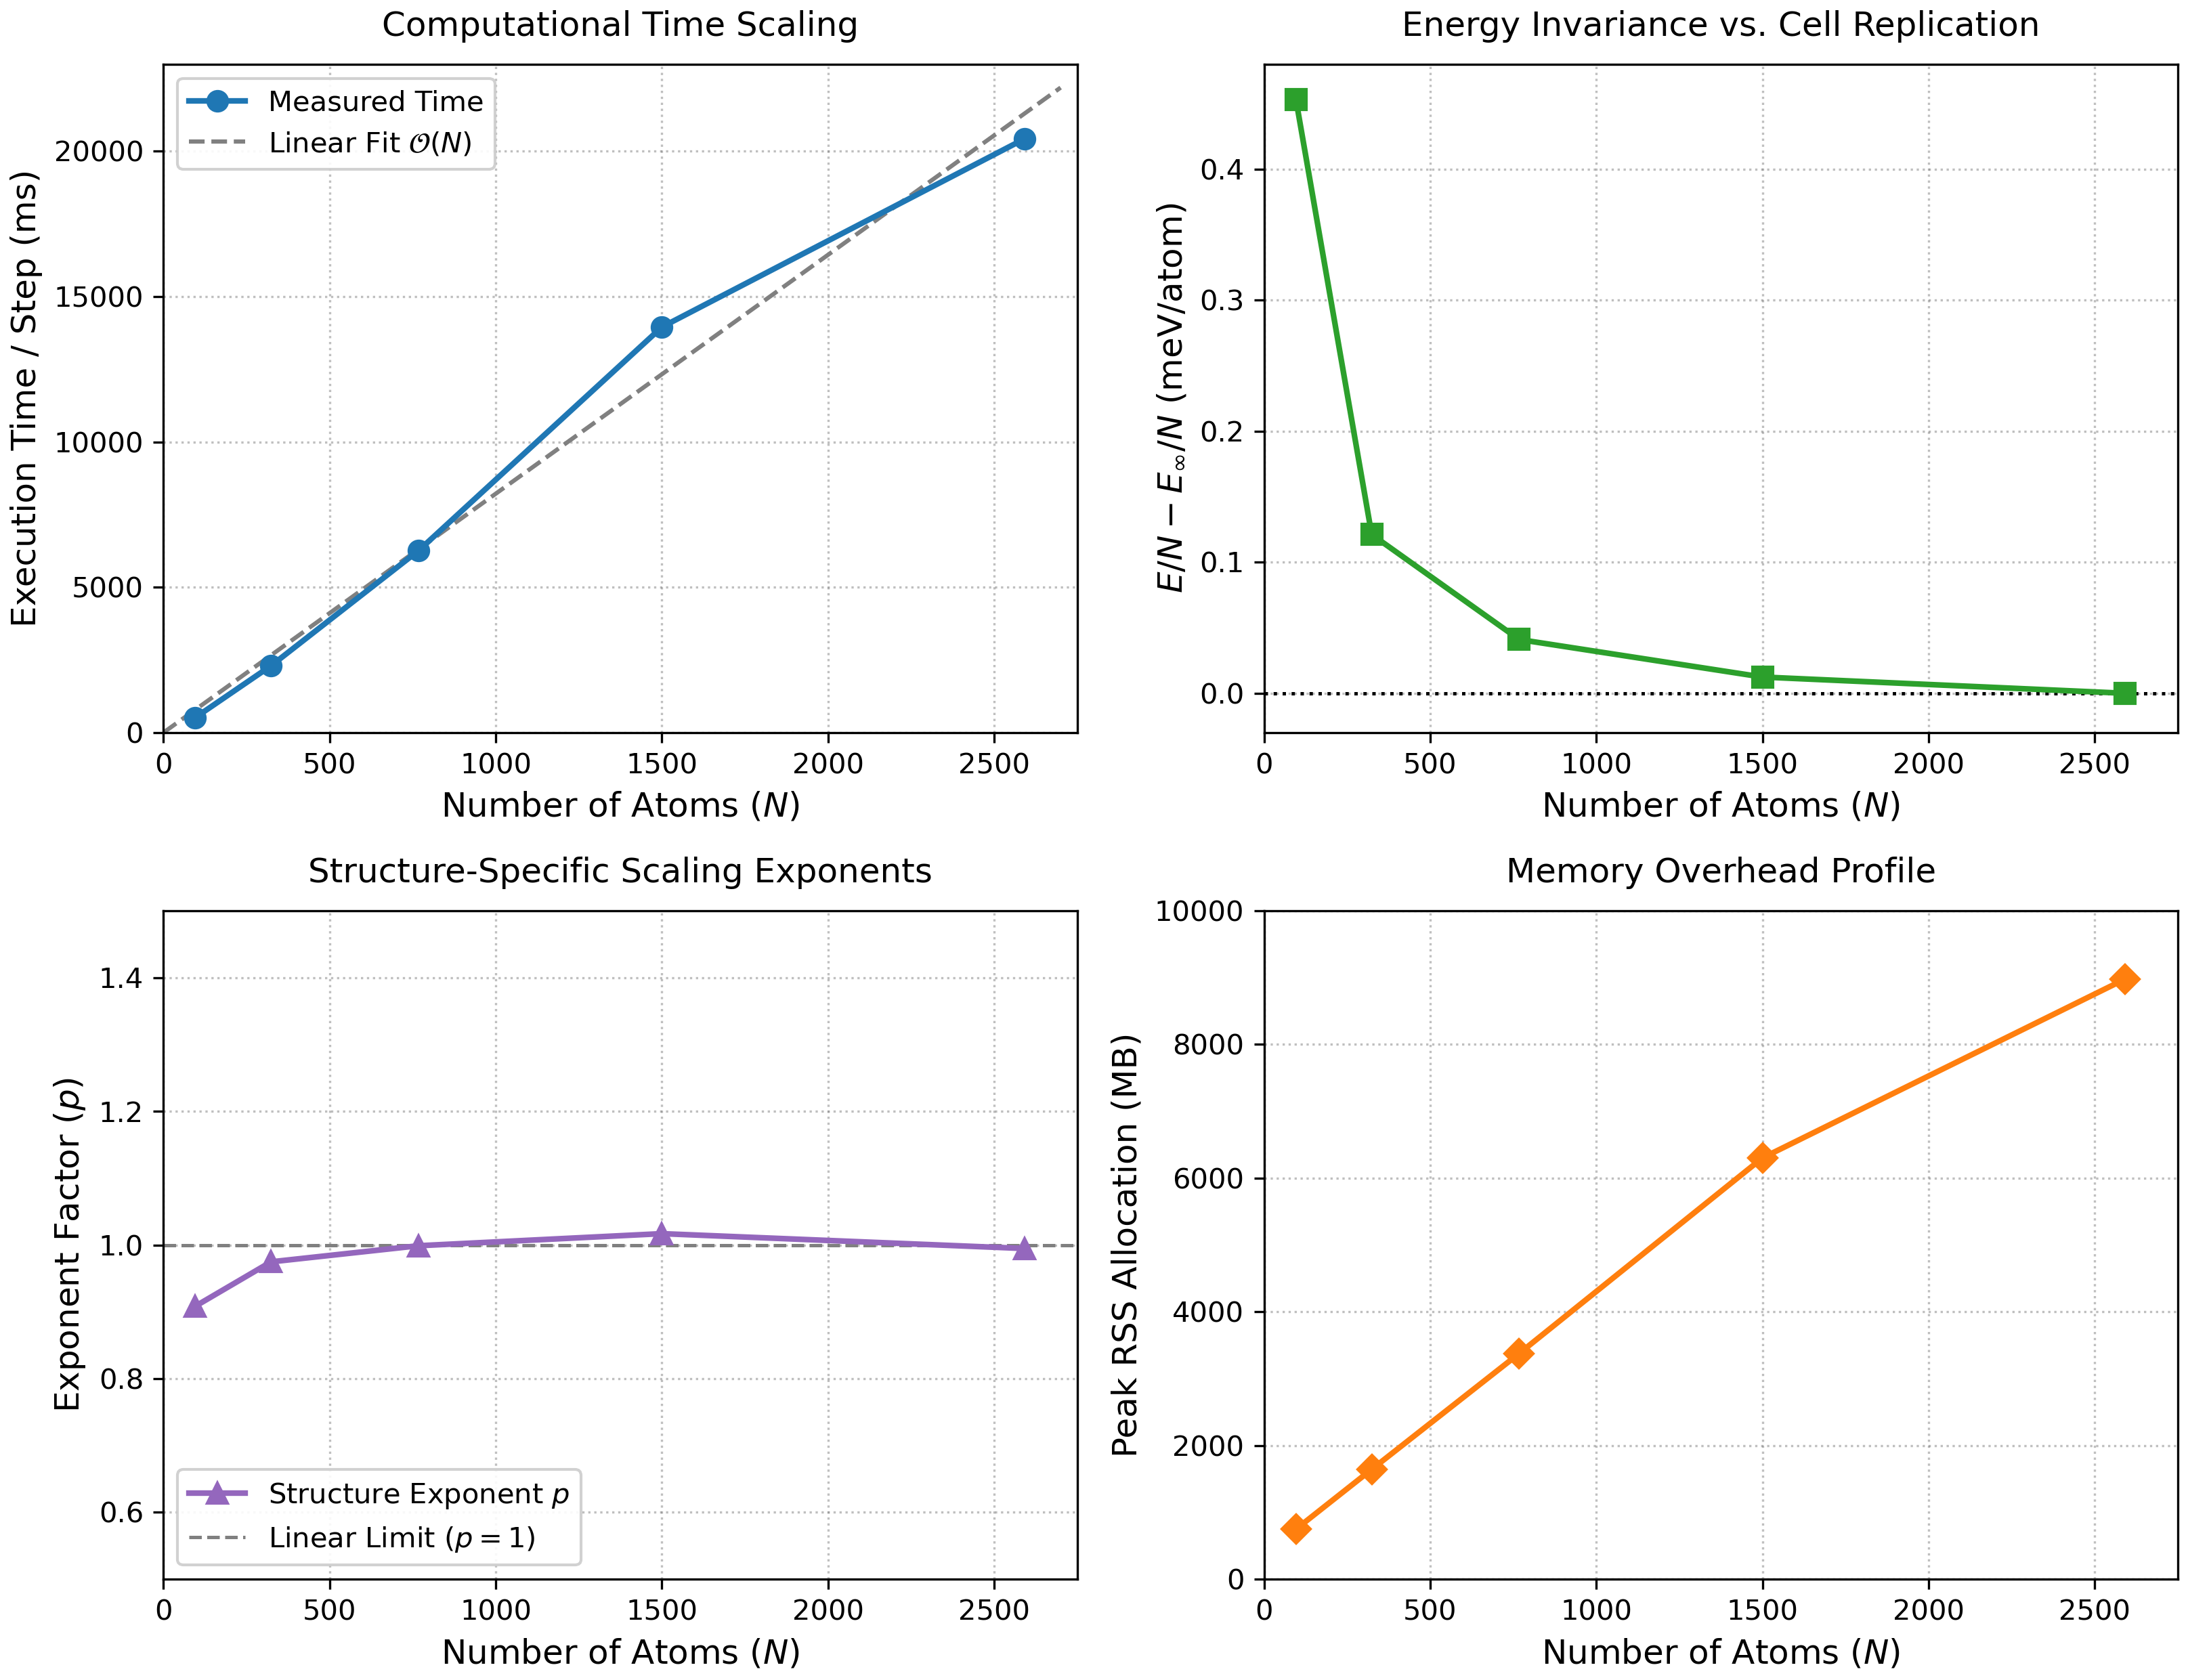

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. RAW COHESIVE BENCHMARK DATA (5 Unique System Sizes)
# =====================================================================
atoms = np.array([96, 324, 768, 1500, 2592])
time_ms = np.array([519.40, 2301.81, 6264.62, 13953.57, 20432.94])
rss_mb = np.array([748.2, 1643.4, 3377.7, 6302.2, 8979.2])
e_atom = np.array([-11.01143932, -11.01177120, -11.01185131, -11.01187992, -11.01189232])

# ---------------------------------------------------------------------
# METRIC TRANSFORMATION & POINT-BY-POINT EXTRACTIONS
# ---------------------------------------------------------------------
# Energy deviation relative to largest cell limit (E_infinity) in meV/atom
e_inf = e_atom[-1]
e_dev_mev = (e_atom - e_inf) * 1000.0

# Extract prefactor 'c' from the reference linear fit line passing through origin
c_prefactor = np.sum(atoms * time_ms) / np.sum(atoms**2)

# Calculate point-by-point effective exponent p for each individual structure:
# t = c * N^p  ==>  p = ln(t / c) / ln(N)
p_exponents = np.log(time_ms / c_prefactor) / np.log(atoms)

# =====================================================================
# 2. DESIGN FRAMEWORK & ACADEMIC VISUAL STYLING
# =====================================================================
plt.rcParams.update({
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family': 'sans-serif'
})

# Generate clean 2x2 presentation grid sheet
fig, axes = plt.subplots(2, 2, figsize=(11, 8.5), dpi=300)

def apply_panel_style(ax, title, ylabel, xlim=(0, 2750), ylim=None):
    ax.set_title(title, pad=10)
    ax.set_xlabel("Number of Atoms ($N$)")
    ax.set_ylabel(ylabel)
    ax.set_xlim(xlim)
    if ylim:
        ax.set_ylim(ylim)
    ax.grid(True, linestyle=':', alpha=0.5, color='gray')

# ---------------------------------------------------------------------
# PANEL 1 (Top-Left): COMPUTATIONAL TIME SCALING (5 Points - Blue)
# ---------------------------------------------------------------------
ax_time = axes[0, 0]
atoms_fit = np.linspace(0, 2700, 100)
time_fit = c_prefactor * atoms_fit

ax_time.plot(atoms, time_ms, color='#1f77b4', marker='o', markersize=7, linestyle='-', linewidth=2, label="Measured Time", zorder=3)
ax_time.plot(atoms_fit, time_fit, color='gray', linestyle='--', linewidth=1.5, label="Linear Fit $\mathcal{O}(N)$", zorder=2)
apply_panel_style(ax_time, "Computational Time Scaling", "Execution Time / Step (ms)", ylim=(0, 23000))
ax_time.legend(loc="upper left", framealpha=0.9)

# ---------------------------------------------------------------------
# PANEL 2 (Top-Right): ENERGY INVARIANCE (5 Points - Green)
# ---------------------------------------------------------------------
ax_eng = axes[0, 1]
ax_eng.plot(atoms, e_dev_mev, color='#2ca02c', marker='s', markersize=7, linestyle='-', linewidth=2, zorder=3)
ax_eng.axhline(0, color='black', linestyle=':', linewidth=1.2, zorder=2)
apply_panel_style(ax_eng, "Energy Invariance vs. Cell Replication", "$E/N - E_{\infty}/N$ (meV/atom)", ylim=(-0.03, 0.48))

# ---------------------------------------------------------------------
# PANEL 3 (Bottom-Left): INDIVIDUAL SCALING EXPONENT p (5 Points - Purple)
# ---------------------------------------------------------------------
ax_p = axes[1, 0]
ax_p.plot(atoms, p_exponents, color='#9467bd', marker='^', markersize=7, linestyle='-', linewidth=2, zorder=3, label="Structure Exponent $p$")
ax_p.axhline(1.0, color='gray', linestyle='--', linewidth=1.2, zorder=2, label="Linear Limit ($p=1$)")
apply_panel_style(ax_p, "Structure-Specific Scaling Exponents", "Exponent Factor ($p$)", ylim=(0.5, 1.5))
ax_p.legend(loc="lower left", framealpha=0.9)

# ---------------------------------------------------------------------
# PANEL 4 (Bottom-Right): MEMORY OVERHEAD PROFILE (5 Points - Orange)
# ---------------------------------------------------------------------
ax_mem = axes[1, 1]
ax_mem.plot(atoms, rss_mb, color='#ff7f0e', marker='D', markersize=7, linestyle='-', linewidth=2, zorder=3)
apply_panel_style(ax_mem, "Memory Overhead Profile", "Peak RSS Allocation (MB)", ylim=(0, 10000))

# =====================================================================
# 3. GRAPHIC EXPORT EXECUTIONS
# =====================================================================
fig.tight_layout()
plt.savefig("ken_complete_benchmarks_4panel.png", bbox_inches='tight')
print("Successfully generated vector layout sheet.")


📦 Loading pre-compiled graph into memory stream: ../../../New_Clear_waste_1565_ken/KENJI.ptc
⏱️ Benchmark: Timestep & Seed Dependence of Non-Periodic AmO2 Cluster Energy Conservation

▶ Evaluating Timestep Δt = 1.0 fs...
   Seed  42 | Drift:   0.080912 meV/atom/ps | Fluct Ratio: 0.229450
   Seed 101 | Drift:  -0.016901 meV/atom/ps | Fluct Ratio: 0.106365
   Seed 202 | Drift:   0.005031 meV/atom/ps | Fluct Ratio: 0.076419

▶ Evaluating Timestep Δt = 0.5 fs...
   Seed  42 | Drift:   0.066071 meV/atom/ps | Fluct Ratio: 0.190472
   Seed 101 | Drift:   0.108963 meV/atom/ps | Fluct Ratio: 0.197165
   Seed 202 | Drift:   0.176524 meV/atom/ps | Fluct Ratio: 0.255222

▶ Evaluating Timestep Δt = 0.25 fs...
   Seed  42 | Drift:   0.001631 meV/atom/ps | Fluct Ratio: 0.058183
   Seed 101 | Drift:   0.057129 meV/atom/ps | Fluct Ratio: 0.302224
   Seed 202 | Drift:   0.042647 meV/atom/ps | Fluct Ratio: 0.083441

✅ Figure saved successfully to: Cmo2_periodic_NVE.pdf


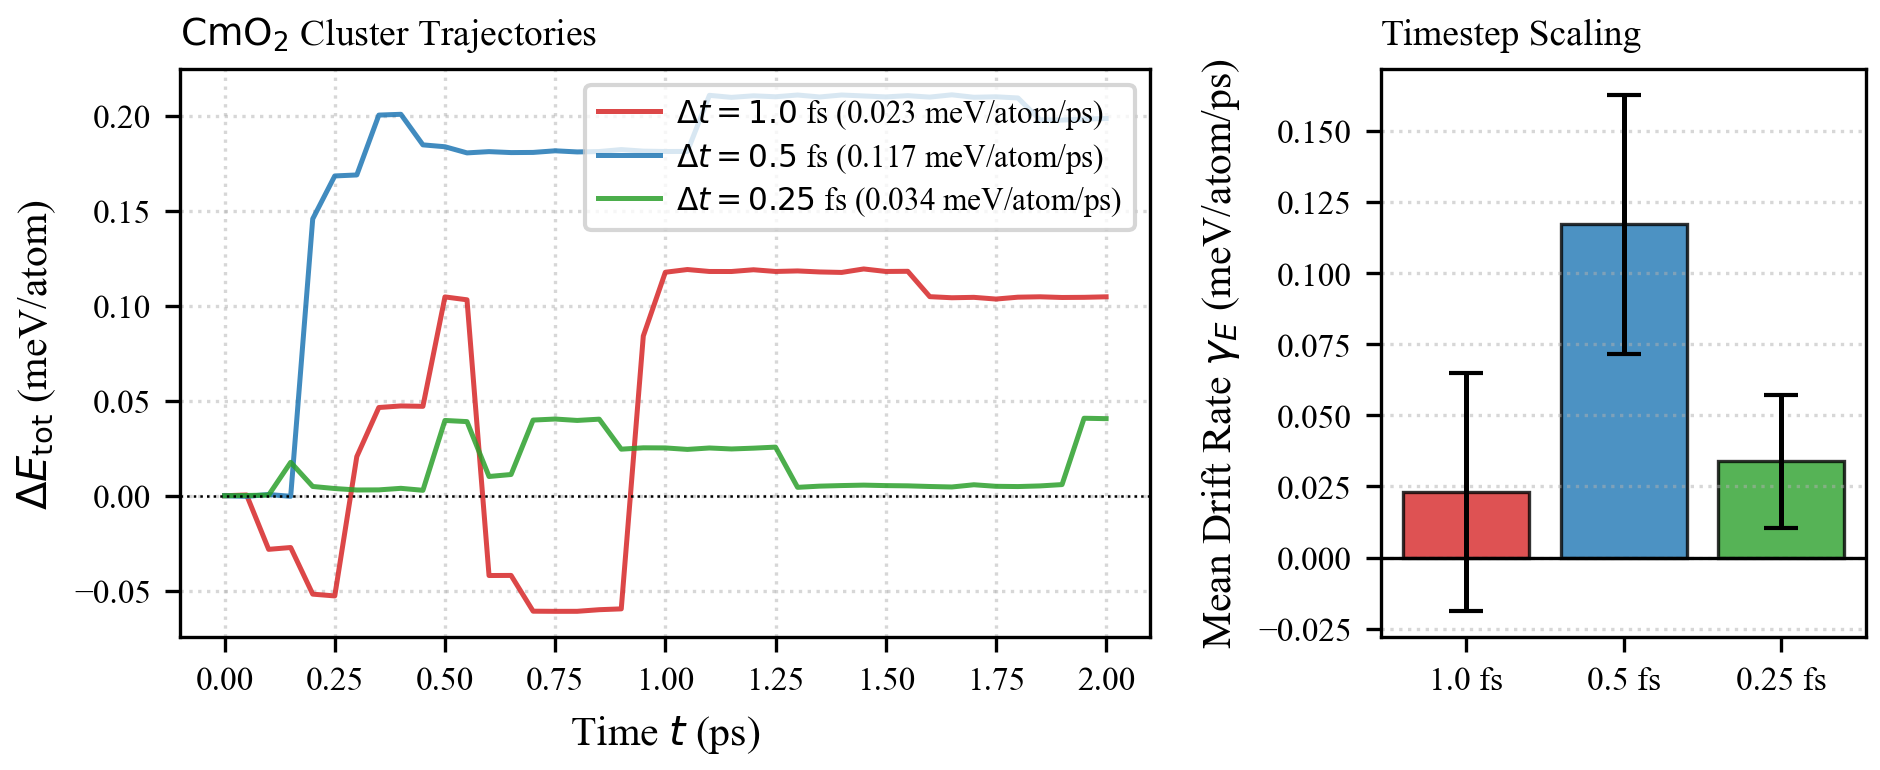

In [9]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
from scipy.stats import linregress

from ase import Atoms, units
from ase.io import read
from ase.constraints import FixCom
from ase.md.langevin import Langevin
from ase.md.verlet import VelocityVerlet
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary

# Assumes CompiledMLIPCalculator is defined in your execution environment

def get_device():
    """Forces CPU execution to prevent TorchScript CPU-traced tensor mismatch."""
    return torch.device("cpu")

def build_amo2_cluster_from_cif(cif_path="AmO2.cif", supercell_dim=(1, 1, 1), radius_angstrom=None):
    """
    Loads AmO2 CIF, expands into a supercell, strips PBC, 
    and optionally trims into a spherical cluster.
    """
    if not os.path.exists(cif_path):
        raise FileNotFoundError(f"CIF file '{cif_path}' not found.")
    
    # 1. Load and replicate unit cell
    bulk = read(cif_path)
    supercell = bulk * supercell_dim
    
    # 2. Center atomic positions
    pos = supercell.get_positions()
    center_pt = pos.mean(axis=0)
    pos_centered = pos - center_pt

    # 3. Optional spherical trimming
    if radius_angstrom is not None:
        distances = np.linalg.norm(pos_centered, axis=1)
        mask = distances <= radius_angstrom
        cluster_symbols = np.array(supercell.get_chemical_symbols())[mask]
        cluster_positions = pos_centered[mask]
    else:
        cluster_symbols = supercell.get_chemical_symbols()
        cluster_positions = pos_centered

    # 4. Construct non-periodic cluster (pbc=False) with non-interacting vacuum padding
    cluster = Atoms(symbols=cluster_symbols, positions=cluster_positions, pbc=False)
    cluster.center(vacuum=12.0)
    return cluster

def run_single_nve_timestep(calc, cif_path, seed=42, dt_fs=0.5, temp_K=300.0, total_ps=2.0):
    """Runs NVE trajectory for a finite non-periodic AmO2 cluster."""
    cluster = build_amo2_cluster_from_cif(cif_path=cif_path, supercell_dim=(1, 1, 1))
    cluster.calc = calc
    num_atoms = len(cluster)
    nve_steps = int((total_ps * 1000.0) / dt_fs)

    # Velocity initialization & Center-of-Mass fix for non-periodic clusters
    MaxwellBoltzmannDistribution(cluster, temperature_K=temp_K, rng=np.random.RandomState(seed))
    Stationary(cluster)
    cluster.set_constraint(FixCom())

    # NVT Pre-equilibration
    nvt = Langevin(cluster, timestep=dt_fs * units.fs, temperature_K=temp_K, friction=0.02, fixcm=False)
    nvt.run(steps=int(2000 / dt_fs))

    # NVE Production Run
    dyn_nve = VelocityVerlet(cluster, timestep=dt_fs * units.fs)
    time_track, tot_track, kin_track = [], [], []

    def log_step():
        epot = cluster.get_potential_energy() / num_atoms
        ekin = cluster.get_kinetic_energy() / num_atoms
        etot = epot + ekin
        step = dyn_nve.get_number_of_steps()
        t_ps = step * dt_fs / 1000.0
        
        time_track.append(t_ps)
        tot_track.append(etot)
        kin_track.append(ekin)

    log_int = max(1, int(100 / (dt_fs / 0.5)))
    dyn_nve.attach(log_step, interval=log_int)
    dyn_nve.run(steps=nve_steps)

    t_arr = np.array(time_track)
    tot_arr = np.array(tot_track)
    kin_arr = np.array(kin_track)

    slope, _, _, _, _ = linregress(t_arr, tot_arr)
    drift_rate = slope * 1000.0  # meV/atom/ps
    fluct_ratio = np.std(tot_arr) / np.std(kin_arr)

    return t_arr, tot_arr, drift_rate, fluct_ratio

def setup_publication_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif"],
        "axes.labelsize": 10,
        "axes.titlesize": 10,
        "legend.fontsize": 7.5,      # Clean presentation match
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "lines.linewidth": 1.2,
        "figure.dpi": 300,
        "savefig.dpi": 600,
        "savefig.bbox": "tight",
        "savefig.pad_inches": 0.05
    })

def generate_amo2_cluster_figure(cif_path="AmO2.cif", timesteps=[1.0, 0.5, 0.25], seeds=[42, 101, 202], output_filename="Cmo2_periodic_NVE.pdf"):
    device = get_device()
    calc = CompiledMLIPCalculator("../../../New_Clear_waste_1565_ken/KENJI.ptc", device=device, r_cut=5.0)
    setup_publication_style()

    results = {}
    print("=" * 70)
    print("⏱️ Benchmark: Timestep & Seed Dependence of Non-Periodic AmO2 Cluster Energy Conservation")
    print("=" * 70)

    for dt in timesteps:
        results[dt] = {'drifts': [], 'flucts': [], 'time': None, 'etot': None}
        print(f"\n▶ Evaluating Timestep Δt = {dt} fs...")
        for s in seeds:
            t_arr, tot_arr, drift, fluct = run_single_nve_timestep(calc, cif_path, seed=s, dt_fs=dt)
            results[dt]['drifts'].append(drift)
            results[dt]['flucts'].append(fluct)
            
            # Store primary trajectory line for Panel A
            if s == seeds[0]:
                results[dt]['time'] = t_arr
                results[dt]['etot'] = tot_arr
            print(f"   Seed {s:3d} | Drift: {drift:10.6f} meV/atom/ps | Fluct Ratio: {fluct:8.6f}")

    # Plotting Grid
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6.5, 2.8), gridspec_kw={'width_ratios': [2.0, 1.0]})
    colors = {0.25: '#2ca02c', 0.5: '#1f77b4', 1.0: '#d62728'}

    # Panel A: Trajectory comparison across timesteps
    for dt in timesteps:
        t = results[dt]['time']
        e_rel = (results[dt]['etot'] - results[dt]['etot'][0]) * 1000.0
        mean_drift = np.mean(results[dt]['drifts'])
        ax1.plot(t, e_rel, color=colors[dt], alpha=0.85, label=f"$\\Delta t = {dt}$ fs ({mean_drift:.3f} meV/atom/ps)")

    ax1.axhline(0, color='black', linewidth=0.6, linestyle=':')
    ax1.set_xlabel(r"Time $t$ (ps)")
    ax1.set_ylabel(r"$\Delta E_{\mathrm{tot}}$ (meV/atom)")
    ax1.set_title(r"$\mathrm{CmO}_2$ Cluster Trajectories", loc='left', fontsize=9)
    
    # MODIFIED: Re-activated and moved label box to upper right with padding limits
    ax1.legend(
        frameon=True, 
        loc="upper right", 
        borderpad=0.4, 
        labelspacing=0.3,
        handletextpad=0.5
    )
    ax1.grid(True, linestyle=":", alpha=0.5)

    # Panel B: Multi-seed Bar Plot with Standard Errors
    mean_drifts = [np.mean(results[dt]['drifts']) for dt in timesteps]
    std_drifts = [np.std(results[dt]['drifts']) for dt in timesteps]

    x_pos = np.arange(len(timesteps))
    dt_labels = [f"{dt} fs" for dt in timesteps]

    ax2.bar(x_pos, mean_drifts, yerr=std_drifts, capsize=4, color=[colors[dt] for dt in timesteps], alpha=0.8, edgecolor='black', linewidth=0.8)
    ax2.axhline(0, color='black', linewidth=0.8, linestyle='-')
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(dt_labels)
    ax2.set_ylabel(r"Mean Drift Rate $\gamma_E$ (meV/atom/ps)")
    ax2.set_title(r"Timestep Scaling", loc='left', fontsize=9)
    ax2.grid(True, linestyle=":", alpha=0.5, axis='y')

    plt.tight_layout()
    plt.savefig(output_filename)
    plt.savefig(output_filename.replace(".pdf", ".png"))
    print(f"\n✅ Figure saved successfully to: {output_filename}")
    plt.show()

if __name__ == "__main__":
    generate_amo2_cluster_figure(cif_path="CmO2.cif")


🖥️ Target Compute Context Assigned: cpu
📦 Loading pre-compiled graph into memory stream: KENJI.ptc
📖 Parsing experimental crystal lattice coordinates from: AmO2.cif

🚀 Step 2: Launching 40 ps Production Langevin MD at 1400 K using Refined Model...
🕒 MD Progress Step | Temperature Profile Tracker: 0.0 K
🕒 MD Progress Step | Temperature Profile Tracker: 1207.6 K
🕒 MD Progress Step | Temperature Profile Tracker: 2228.7 K
🕒 MD Progress Step | Temperature Profile Tracker: 2157.6 K
🕒 MD Progress Step | Temperature Profile Tracker: 2147.9 K
🕒 MD Progress Step | Temperature Profile Tracker: 1653.7 K
🕒 MD Progress Step | Temperature Profile Tracker: 1506.5 K
🕒 MD Progress Step | Temperature Profile Tracker: 1690.4 K
🕒 MD Progress Step | Temperature Profile Tracker: 1778.6 K
🕒 MD Progress Step | Temperature Profile Tracker: 1985.2 K
🕒 MD Progress Step | Temperature Profile Tracker: 1722.6 K
🕒 MD Progress Step | Temperature Profile Tracker: 1654.4 K
🕒 MD Progress Step | Temperature Profile Tracke

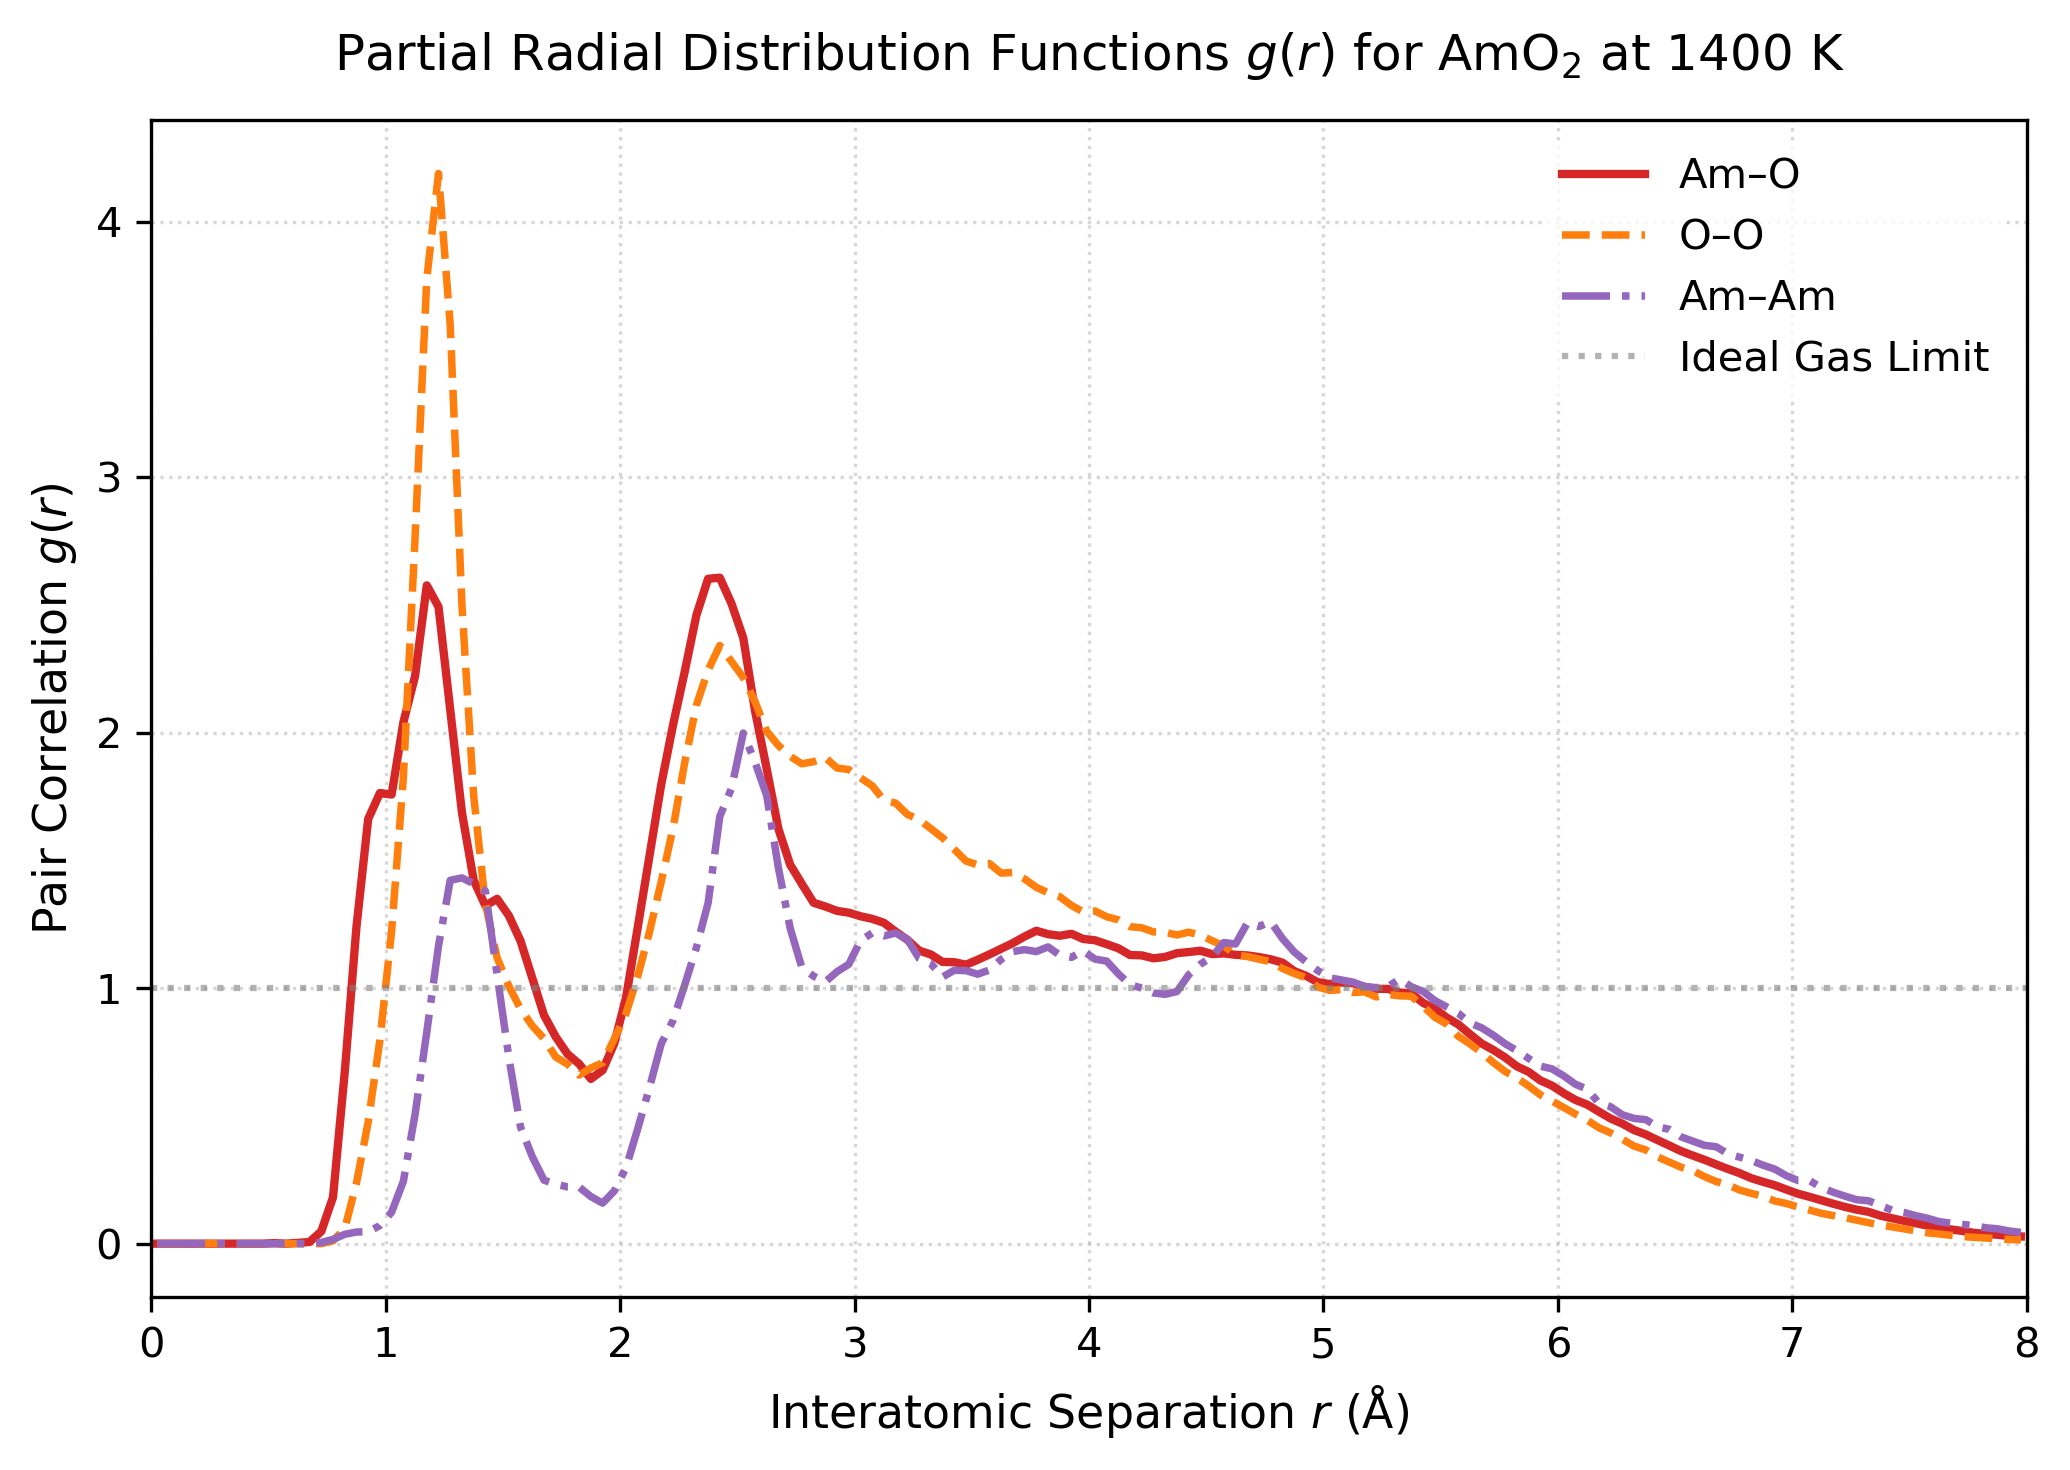

In [3]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from ase import units
from ase.io import read
from ase.io.trajectory import Trajectory
from ase.optimize import BFGS
from ase.md.langevin import Langevin

# Explicit path definition pointing to your compiled 1565 dataset model
#KENJI_MODEL_PATH = "../../../New_Clear_waste_1565_ken/KENJI.ptc"
KENJI_MODEL_PATH = "KENJI.ptc"

def compute_rdf(trajectory_path, r_max=8.0, dr=0.05, skip_first_pct=0.2):
    """
    Reads the NVE/Langevin trajectory and computes normalized Radial Distribution 
    Functions g(r) for Cm-Cm, O-O, and Cm-O atom pairs under periodic boundaries.
    """
    print("\n📊 Parsing trajectory frames to extract structural RDF correlation fields...")
    traj = Trajectory(trajectory_path)
    num_frames = len(traj)
    
    start_frame = int(num_frames * skip_first_pct)
    analyzed_frames = traj[start_frame:]
    
    bins = np.arange(0, r_max + dr, dr)
    r_centers = bins[:-1] + dr / 2.0
    
    counts = {"Am-Am": np.zeros(len(r_centers)), 
              "O-O": np.zeros(len(r_centers)), 
              "Am-O": np.zeros(len(r_centers))}
    
    ref_atoms = traj[0]
    symbols = np.array(ref_atoms.get_chemical_symbols())
    idx_Cm = np.where(symbols == 'Am')[0]
    idx_O = np.where(symbols == 'O')[0]
    
    n_Cm = len(idx_Cm)
    n_O = len(idx_O)
    volume = ref_atoms.get_volume()
    
    for atoms in analyzed_frames:
        distances = atoms.get_all_distances(mic=True)
        
        # 1. Cm-Cm Pair Correlator
        if n_Cm > 1:
            d_Cm_Cm = distances[idx_Cm][:, idx_Cm]
            d_Cm_Cm = d_Cm_Cm[~np.eye(n_Cm, dtype=bool)]
            hist, _ = np.histogram(d_Cm_Cm, bins=bins)
            counts["Am-Am"] += hist
        
        # 2. O-O Pair Correlator
        if n_O > 1:
            d_O_O = distances[idx_O][:, idx_O]
            d_O_O = d_O_O[~np.eye(n_O, dtype=bool)]
            hist, _ = np.histogram(d_O_O, bins=bins)
            counts["O-O"] += hist
        
        # 3. Cm-O Hetero-pair Cross-Correlator
        if n_Cm > 0 and n_O > 0:
            d_Cm_O = distances[idx_Cm][:, idx_O].flatten()
            hist, _ = np.histogram(d_Cm_O, bins=bins)
            counts["Am-O"] += hist

    num_sampled_frames = len(analyzed_frames)
    shell_volumes = 4.0 * np.pi * (r_centers**2) * dr
    
    g_r = {}
    g_r["Am-Am"] = (counts["Am-Am"] / num_sampled_frames) / (shell_volumes * (n_Cm * (n_Cm - 1) / volume)) if n_Cm > 1 else np.zeros_like(r_centers)
    g_r["O-O"] = (counts["O-O"] / num_sampled_frames) / (shell_volumes * (n_O * (n_O - 1) / volume)) if n_O > 1 else np.zeros_like(r_centers)
    g_r["Am-O"] = (counts["Am-O"] / num_sampled_frames) / (shell_volumes * (n_Cm * n_O / volume)) if (n_Cm > 0 and n_O > 0) else np.zeros_like(r_centers)
    
    return r_centers, g_r

def plot_rdfs(r_centers, g_r):
    """Saves and renders a publication-ready Cm-oxide RDF profile."""
    plt.figure(figsize=(7, 5), dpi=300)
    
    plt.plot(r_centers, g_r["Am-O"], label=r"Am–O", color="#d62728", linewidth=2)
    plt.plot(r_centers, g_r["O-O"], label=r"O–O", color="#ff7f0e", linewidth=1.8, linestyle="--")
    plt.plot(r_centers, g_r["Am-Am"], label=r"Am–Am", color="#9467bd", linewidth=1.8, linestyle="-.")
    
    plt.title("Partial Radial Distribution Functions $g(r)$ for $\mathrm{AmO_2}$ at 1400 K", fontsize=12, pad=12)
    plt.xlabel("Interatomic Separation $r$ (Å)", fontsize=11)
    plt.ylabel("Pair Correlation $g(r)$", fontsize=11)
    plt.xlim(0, 8.0)
    plt.grid(True, linestyle=":", alpha=0.5)
    plt.axhline(1.0, color="gray", linestyle=":", alpha=0.6, label="Ideal Gas Limit")
    plt.legend(frameon=True, facecolor="white", edgecolor="none", fontsize=10)
    plt.tight_layout()
    
    output_image = "figures/AmO2_1400K_RDF.png"
    os.makedirs("figures", exist_ok=True)
    plt.savefig(output_image)
    print(f"🎉 Refined RDF Output Plot compiled safely: {output_image}")
    plt.show()

def main():
    device = torch.device("cpu")
    print(f"🖥️ Target Compute Context Assigned: {device}")
    
    # Verify presence of the newly specified 1565 network footprint path 
    if not os.path.exists(KENJI_MODEL_PATH):
        raise FileNotFoundError(f"❌ Cannot locate compiled model backend path: {KENJI_MODEL_PATH}")
    
    calc = CompiledMLIPCalculator(KENJI_MODEL_PATH, device, r_cut=5.0)
    
    # Target file set to your curium crystal footprint reference coordinate database
    cif_file_path = "AmO2.cif" 
    if not os.path.exists(cif_file_path):
        raise FileNotFoundError(f"❌ Missing mandatory CIF structural input path: {cif_file_path}")

    print(f"📖 Parsing experimental crystal lattice coordinates from: {cif_file_path}")
    unit_cell = read(cif_file_path)
    
    # Replicate into standard 2x2x2 periodic block boundaries
    bulk_structure = unit_cell * (2, 2, 2)
    bulk_structure.set_pbc((True, True, True))
    bulk_structure.set_initial_magnetic_moments(np.ones(len(bulk_structure)) * 2.0)
    bulk_structure.calc = calc

    # --------------------------------------------------------
    # STEP 1: INITIAL BFGS STRUCTURAL MINIMIZATION
    # --------------------------------------------------------
    '''print("\n⏳ Step 1: Running Initial Geometry Relaxation...")
    opt = BFGS(bulk_structure, trajectory='relaxation_track.traj')
    opt.run(fmax=0.05, steps=500) 
    relaxed_cell = read('relaxation_track.traj', index=-1)
    print(f"📐 Relaxed Cell Volume: {relaxed_cell.get_volume():.3f} Å³")'''

    # --------------------------------------------------------
    # STEP 2: HIGH-TEMPERATURE LANGEVIN MOLECULAR DYNAMICS (40 ps)
    # --------------------------------------------------------
    print("\n🚀 Step 2: Launching 40 ps Production Langevin MD at 1400 K using Refined Model...")
    md_atoms = bulk_structure.copy()
    md_atoms.calc = calc
    
    def log_langevin_progress():
        ekin = float(md_atoms.get_kinetic_energy())
        temp = ekin / (1.5 * units.kB * len(md_atoms))
        print(f"🕒 MD Progress Step | Temperature Profile Tracker: {temp:.1f} K")

    dyn_langevin = Langevin(md_atoms, timestep=1.0 * units.fs, temperature_K=1400, friction=0.02, fixcm=False)
    trajectory_file = 'bulk_AmO2_fluorite.traj'
    traj_langevin = Trajectory(trajectory_file, 'w', md_atoms)
    
    dyn_langevin.attach(traj_langevin, interval=20)
    dyn_langevin.attach(log_langevin_progress, interval=1000)
    
    # 40 ps simulation timeframe (40,000 steps at Δt = 1.0 fs)
    dyn_langevin.run(steps=40000) 
    print(f"🏁 Production Langevin run complete. Trajectory array cached in '{trajectory_file}'.")

    # --------------------------------------------------------
    # STEP 3: RADIAL DISTRIBUTION FUNCTION PROCESSING
    # --------------------------------------------------------
    r_centers, g_r = compute_rdf(trajectory_file, r_max=8.0, dr=0.05, skip_first_pct=0.2)
    plot_rdfs(r_centers, g_r)

if __name__ == "__main__":
    main()


In [5]:
!ase gui bulk_cmo_fluorite.traj